# Drowsiness Detection — Eye State Classification

Binary classification of infrared eye images into **Awake** and **Sleepy** states using transfer learning.  
Dataset: [MRL Eye Dataset](http://mrl.cs.vsb.cz/eyedataset) — ~85K infrared images across train / val / test splits.

**Models trained:** ResNet50 · InceptionV3  
**Framework:** PyTorch · TorchVision


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# TorchVision
import torchvision.transforms.v2 as v2
from torchvision.models import inception_v3, resnet50, ResNet50_Weights, Inception_V3_Weights
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# Data utilities
from torch.utils.data.dataloader import DataLoader
from sklearn.utils import shuffle
from tqdm import tqdm

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


## 1. Configuration

In [ ]:
TRAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\train"
VAL_PATH   = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\val"
TEST_PATH  = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\mrl-eye-dataset\test"

SIZE       = 224    # input resolution expected by ResNet / InceptionV3
BATCH_SIZE = 128
EPOCHS     = 30
PATIENCE   = 5      # early stopping patience
LR         = 1e-5


## 2. Exploratory Data Analysis

In [ ]:
def show_all_images_counts(all_path: list):
    """Count images per class for each split."""
    all_images_counts = {}
    for path in all_path:
        labels = os.listdir(path)
        img_counts = {}
        for label_name in labels:
            label_path = os.path.join(path, label_name)
            img_counts[label_name] = len(os.listdir(label_path))
        all_images_counts[path.split("\\")[-1]] = img_counts
    return all_images_counts

all_counts = show_all_images_counts([TRAIN_PATH, VAL_PATH, TEST_PATH])


In [ ]:
print(f"All Images Counts In Train: {all_counts["train"]}\n")
print(f"All Images Counts In Val: {all_counts["val"]}\n")
print(f"All Images Counts In Test: {all_counts["test"]}\n")

All Images Counts In Train: {'awake': 25770, 'sleepy': 25167}

All Images Counts In Val: {'awake': 8591, 'sleepy': 8389}

All Images Counts In Test: {'awake': 8591, 'sleepy': 8390}



In [ ]:
def show_all_sizes(all_path: list):
    """Collect unique image dimensions across each split to check for size inconsistencies."""
    all_sizes = {}
    for path in all_path:
        labels = os.listdir(path)
        sizes = []
        for label_name in labels:
            label_path = os.path.join(path, label_name)
            for img in os.listdir(label_path):
                sizes.append(plt.imread(os.path.join(label_path, img)).shape)
        all_sizes[path.split("\\")[-1]] = set(sizes)
    return all_sizes

all_sizes = show_all_sizes([TRAIN_PATH, VAL_PATH, TEST_PATH])


In [ ]:
print(f"All Sizes In Train: {all_sizes["train"]}\n Value Counts: {len(all_sizes["train"])}\n")
print(f"All Sizes In Val: {all_sizes["val"]}\n Value Counts: {len(all_sizes["val"])}\n")
print(f"All Sizes In Test: {all_sizes["test"]}\n Value Counts: {len(all_sizes["test"])}\n")

All Sizes In Train: {(267, 267), (84, 84), (277, 277), (116, 116), (61, 61), (126, 126), (181, 181), (272, 272), (176, 176), (153, 153), (208, 208), (218, 218), (57, 57), (122, 122), (117, 117), (94, 94), (149, 149), (214, 214), (209, 209), (241, 241), (58, 58), (90, 90), (246, 246), (150, 150), (127, 127), (182, 182), (242, 242), (297, 297), (274, 274), (91, 91), (68, 68), (123, 123), (63, 63), (183, 183), (238, 238), (160, 160), (215, 215), (64, 64), (220, 220), (59, 59), (124, 124), (101, 101), (156, 156), (216, 216), (248, 248), (65, 65), (97, 97), (253, 253), (92, 92), (157, 157), (212, 212), (189, 189), (184, 184), (194, 194), (88, 88), (98, 98), (286, 286), (70, 70), (125, 125), (180, 180), (190, 190), (245, 245), (222, 222), (217, 217), (227, 227), (121, 121), (66, 66), (282, 282), (131, 131), (186, 186), (158, 158), (213, 213), (223, 223), (62, 62), (278, 278), (72, 72), (250, 250), (260, 260), (99, 99), (154, 154), (164, 164), (219, 219), (159, 159), (191, 191), (256, 256), (

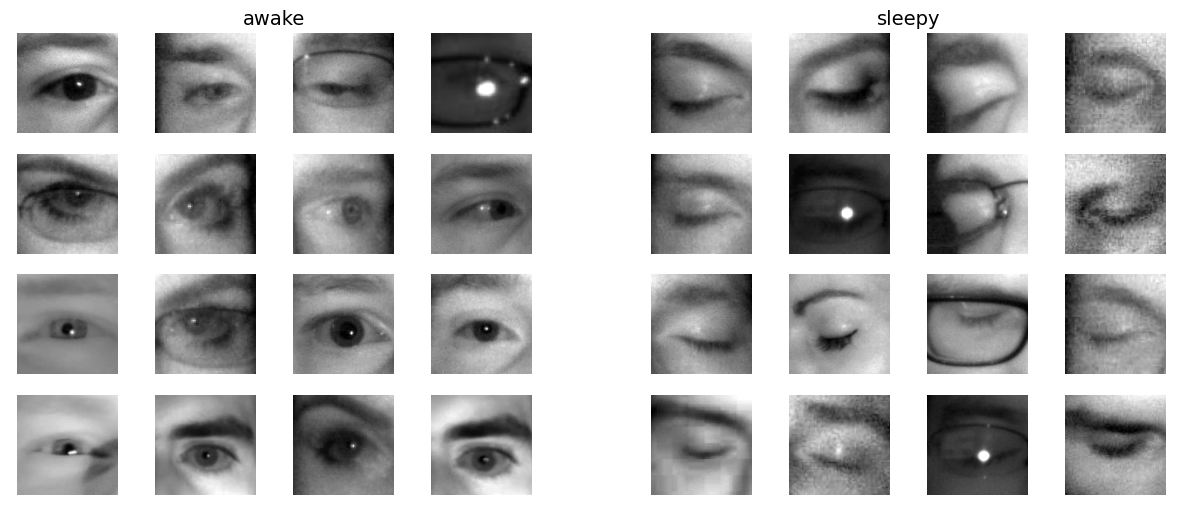

In [ ]:
def show_random_image(PATH, num_of_samples=16):
    """Display a 4x4 grid of random samples per class side by side."""
    labels = os.listdir(PATH)
    fig = plt.figure(figsize=(15, 6))
    outer = fig.add_gridspec(1, 2, wspace=0.2)

    for j, label_name in enumerate(labels[:2]):
        label_path = os.path.join(PATH, label_name)
        images = shuffle(os.listdir(label_path))[:num_of_samples]
        inner = outer[j].subgridspec(4, 4)

        ax_title = fig.add_subplot(outer[j])
        ax_title.set_title(label_name, fontsize=14)
        ax_title.axis("off")

        for i, img_name in enumerate(images):
            r, c = divmod(i, 4)
            ax = fig.add_subplot(inner[r, c])
            ax.imshow(plt.imread(os.path.join(label_path, img_name)), cmap="gray")
            ax.axis("off")

    plt.show()

show_random_image(TRAIN_PATH)


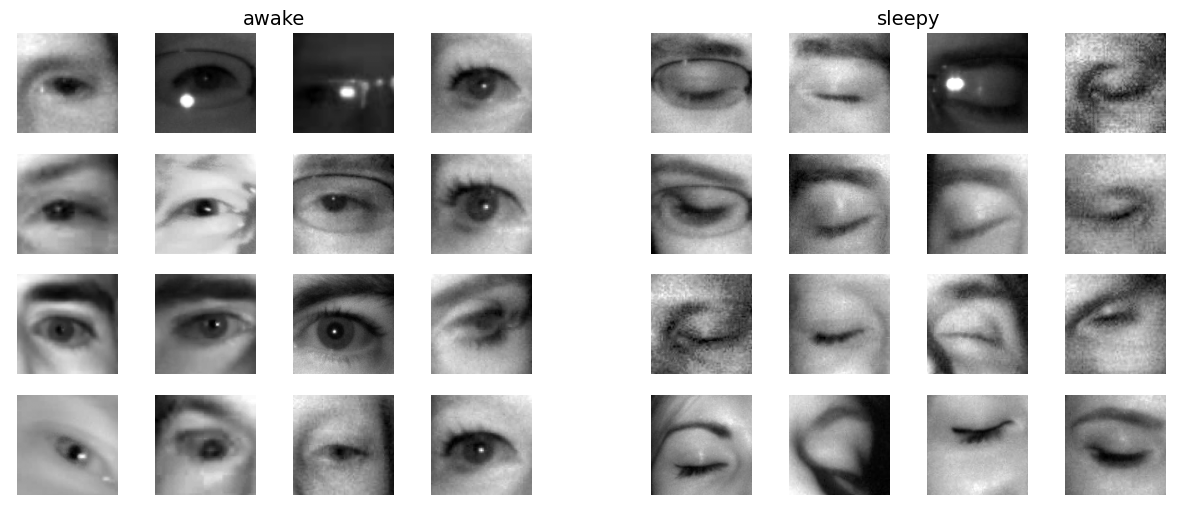

In [ ]:
show_random_image(VAL_PATH)

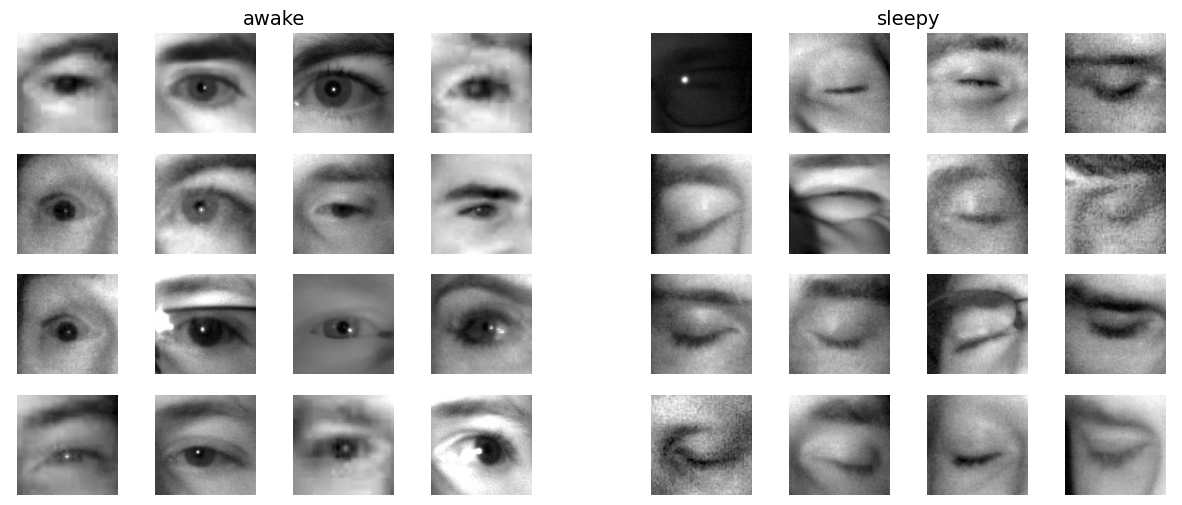

In [ ]:
show_random_image(TEST_PATH)

## 3. Data Pipeline

**Transforms applied:**
- Train: Resize → GaussianBlur → ColorJitter → HorizontalFlip → Rotation → Grayscale → Normalize
- Val / Test: Resize → Grayscale → Normalize

Augmentation is kept light — the dataset is already large (~85K images) and the task is shape-based, so heavy augmentation could hurt more than it helps.


In [ ]:
def get_transforms(size=SIZE, apply_on_train=False):
    """
    Return a transform pipeline for the given split.

    Parameters
    ----------
    size           : int  — target image size (default 224)
    apply_on_train : bool — whether to include data augmentation
    """
    base = [
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    augmentation = [
        v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.2)),
        v2.ColorJitter((0.8, 1.3)),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(30),
    ]

    tail = [
        v2.Grayscale(),
        v2.Normalize((0.5,), (0.5,)),
    ]

    if apply_on_train:
        return v2.Compose(base + augmentation + tail)
    return v2.Compose(base + tail)


In [ ]:
def prepare_dataloader(train_p, val_p, test_p, img_size=SIZE, batch_size=BATCH_SIZE):
    """Load datasets and wrap them in DataLoaders."""
    train_df = ImageFolder(train_p, get_transforms(img_size, apply_on_train=True))
    val_df   = ImageFolder(val_p,   get_transforms(img_size))
    test_df  = ImageFolder(test_p,  get_transforms(img_size))

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    train_dl = DataLoader(train_df, batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_df,   batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_dl  = DataLoader(test_df,  batch_size, shuffle=False, num_workers=0, pin_memory=True)

    print("Data loaded successfully.")
    return train_dl, val_dl, test_dl


In [ ]:
train,val,test = prepare_dataloader(TRAIN_PATH,VAL_PATH,TEST_PATH)

Train length:  50937
Validation length:  16980
Test length:  16981
The Data Is Succssfuly Loaded...!


In [ ]:
imgs , _ = next(iter(train))
imgs[0].shape

torch.Size([3, 224, 224])

In [ ]:
def denorm(imgs):
    """Reverse normalization from [-1, 1] back to [0, 1] for display."""
    return (imgs + 1) / 2


(np.float64(-0.5), np.float64(3617.5), np.float64(1809.5), np.float64(-0.5))

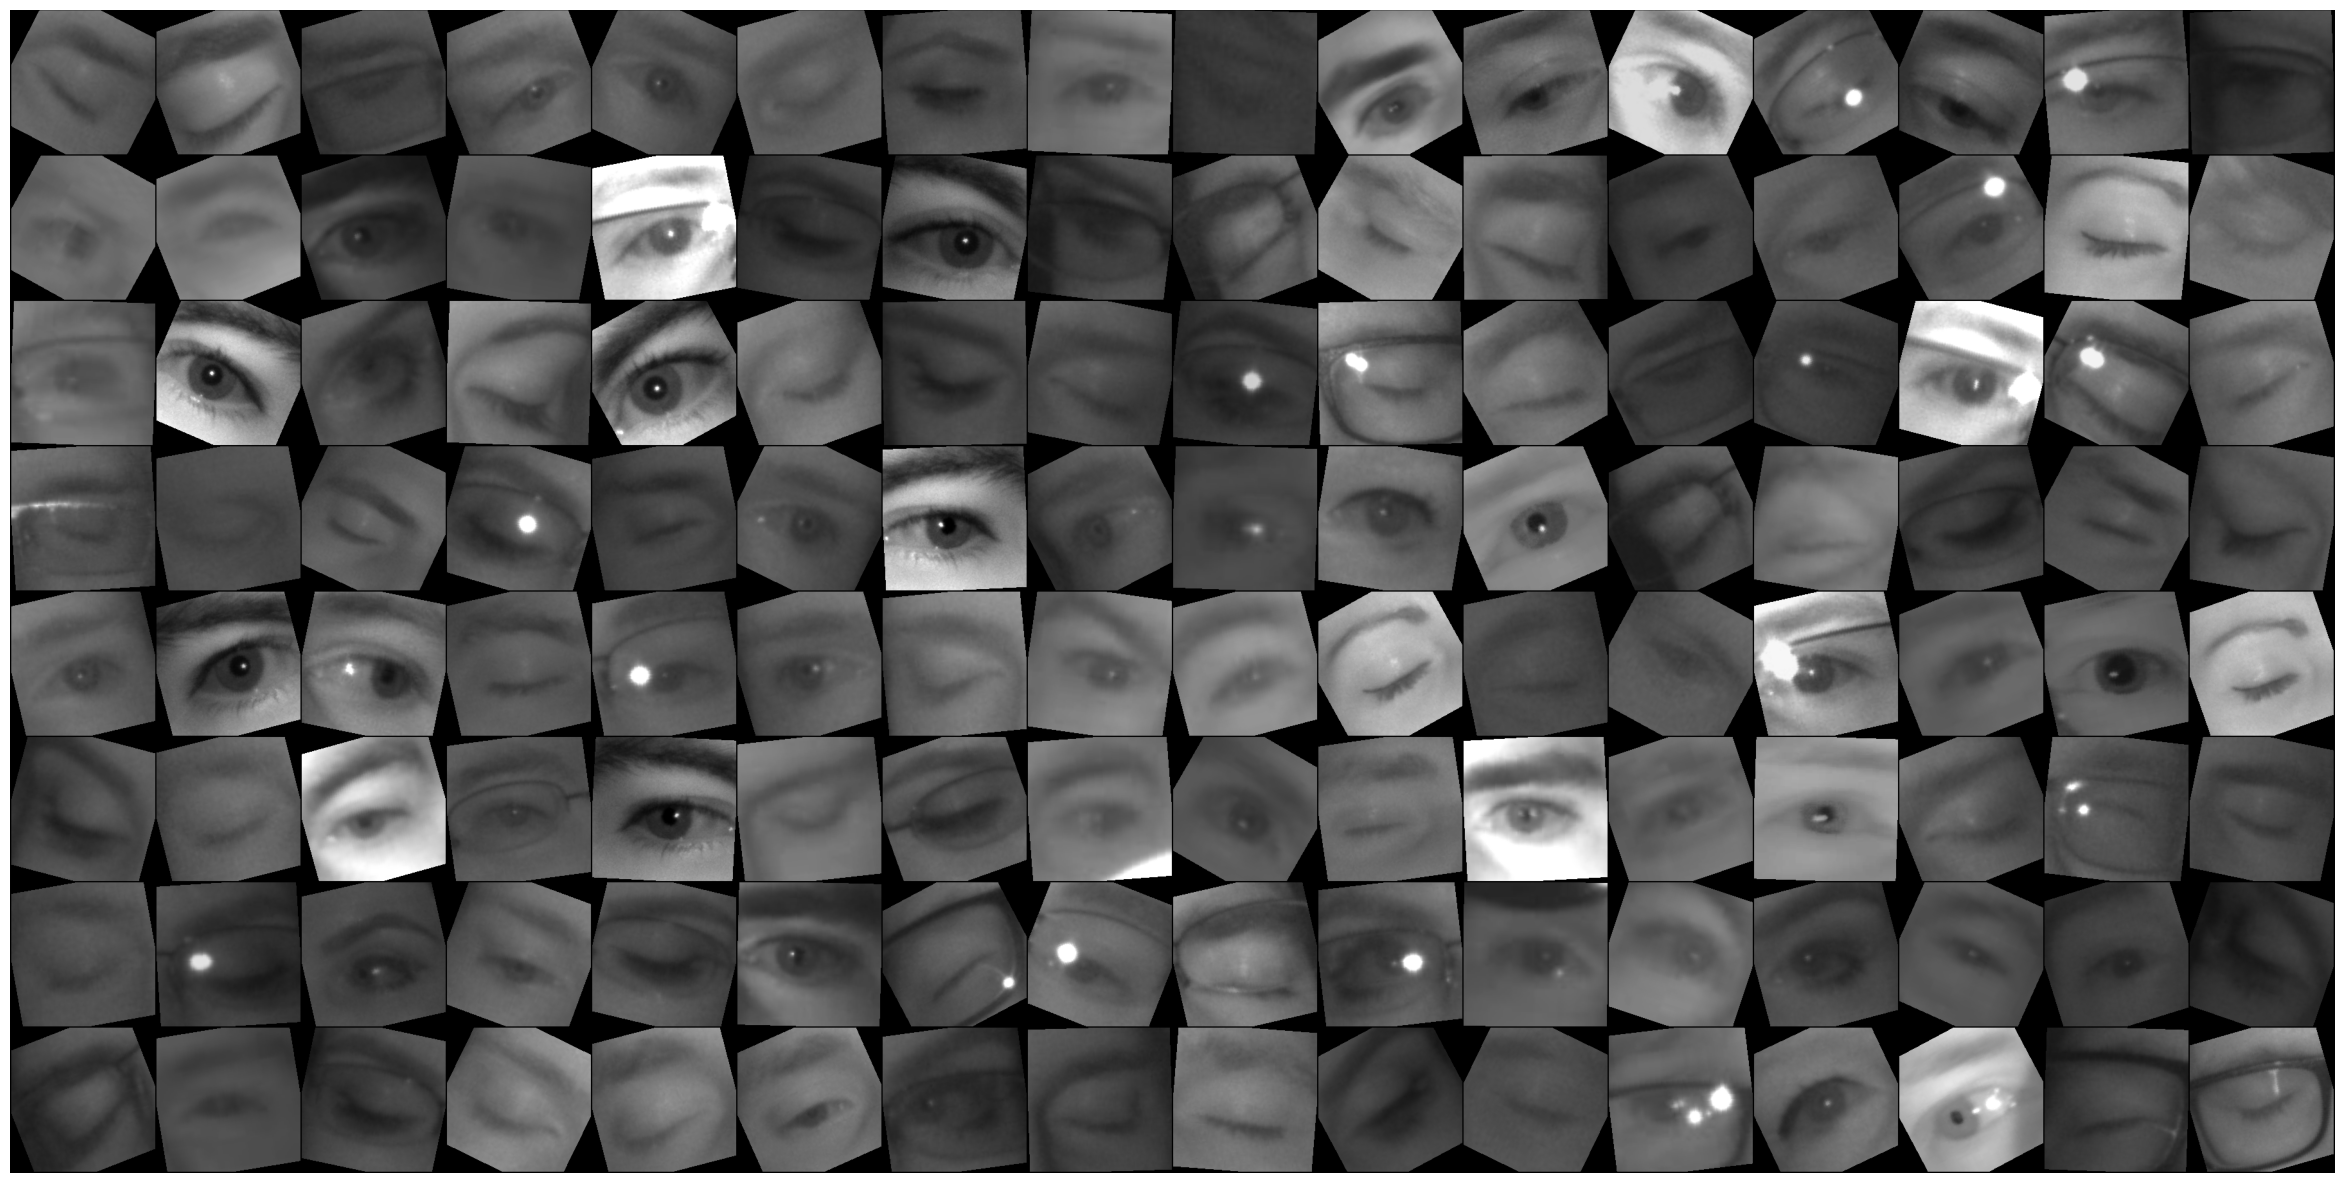

In [ ]:
imgs,labels = next(iter(train))
plt.figure(figsize=(30, 30))

plt.imshow(make_grid(denorm(imgs),16).permute(1,2,0),cmap="gray")
plt.axis("off")

## 4. Model

We use **transfer learning** with ImageNet pretrained weights and replace the final layer with a 2-class head.

- **ResNet50** — `fc` replaced with `Dropout(0.5) → Linear(2048, 2)`
- **InceptionV3** — `classifier` replaced with `Linear(in_features, 2)`

Optimizer: AdamW · Loss: CrossEntropy · Early stopping on validation AUC.


In [ ]:
def replace_classifier(model, name):
    """
    Swap the final classification head for a 2-class output.

    Supported architectures: ResNet, InceptionV3, EfficientNet

    Parameters
    ----------
    model : pretrained PyTorch model
    name  : str — model class name (used to identify head location)
    """
    if "Inception" in name:
        model.classifier = nn.Linear(model.classifier.in_features, 2)

    elif "ResNet" in name:
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(model.fc.in_features, 2)
        )

    elif "EfficientNet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    return model


In [ ]:
def build_model(model_name, weights="DEFAULT", learning_rate=LR):
    """
    Instantiate a pretrained model, replace its head, and set up optimizer.

    Returns
    -------
    (model, criterion, optimizer)
    """
    model = model_name(weights=weights)
    model = replace_classifier(model, name=model.__class__.__name__)
    model = model.to(device)

    criterion = F.cross_entropy
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    return model, criterion, optimizer


## 5. Training

The `fit` function handles:
- Training loop with mixed precision (`torch.autocast`)
- Validation loop with AUC tracking
- Early stopping — saves the best checkpoint by validation AUC


In [ ]:
def fit(model_name, train_data, val_data, model_weights="DEFAULT", epochs=EPOCHS, patiance=PATIENCE, learning_rate=LR):
    model, criterion, opt = build_model(model_name, model_weights, learning_rate)
    name = model.__class__.__name__

    history = []
    best_epoch = 0
    counter = 0
    best_auc = 0

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────
        all_train_loss, all_labels, all_preds = [], [], []
        model.train()

        for imgs, labels in tqdm(train_data, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.autocast(device_type='cuda'):
                outputs = model(imgs).to(device)
                loss = criterion(outputs, labels)

            loss.backward()
            opt.step()
            opt.zero_grad()

            probs = torch.sigmoid(outputs)
            all_train_loss.append(loss.detach().cpu().item())
            all_preds.append(probs.detach().cpu())
            all_labels.append(labels.detach().cpu())

        train_loss = sum(all_train_loss) / len(all_train_loss)
        all_labels_cat = torch.cat(all_labels).numpy()
        all_preds_cat  = torch.cat(all_preds)[:, 1].numpy()  # prob of positive class (sleepy)
        train_auc = roc_auc_score(all_labels_cat, all_preds_cat)

        # ── Validate ────────────────────────────────────────────────────────
        all_val_loss, all_labels, all_preds = [], [], []
        model.eval()
        with torch.no_grad():
            for imgs, labels in val_data:
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.autocast(device_type='cuda'):
                    outputs = model(imgs).to(device)
                    loss = criterion(outputs, labels)
                probs = torch.sigmoid(outputs)
                all_val_loss.append(loss.detach().cpu().item())
                all_preds.append(probs.detach().cpu())
                all_labels.append(labels.detach().cpu())

        val_loss = sum(all_val_loss) / len(all_val_loss)
        all_labels_cat = torch.cat(all_labels).numpy()
        all_preds_cat  = torch.cat(all_preds)[:, 1].numpy()
        val_auc = roc_auc_score(all_labels_cat, all_preds_cat)

        history.append({
            "train_loss": train_loss, "train_auc": train_auc,
            "val_loss": val_loss,     "val_auc": val_auc
        })

        # ── Early stopping ──────────────────────────────────────────────────
        if val_auc > best_auc:
            best_auc   = val_auc
            best_epoch = epoch
            counter    = 0
            torch.save(model.state_dict(), f"best_{name}_model.pth")
            print(f"  New best saved — val AUC: {best_auc:.4f}")
        else:
            counter += 1
            print(f"  No improvement ({counter}/{patiance})")
            if counter >= patiance:
                print("Early stopping triggered.")
                break

    return history, best_epoch


## 6. Evaluation

In [ ]:
def Show_Curves(model_history, name):
    """
    Plot Loss and AUC curves for train and validation splits.
    Saves figure to disk as '<name>_AUC_LOSS_Curves.png'.

    Parameters
    ----------
    model_history : list of dicts — keys: train_loss, val_loss, train_auc, val_auc
    name          : str — model name used in title and filename
    """
    train_loss = [x["train_loss"] for x in model_history]
    val_loss   = [x["val_loss"]   for x in model_history]
    train_auc  = [x["train_auc"]  for x in model_history]
    val_auc    = [x["val_auc"]    for x in model_history]

    _, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(train_loss, label="Train",      linewidth=2)
    ax[0].plot(val_loss,   label="Validation", linewidth=2, linestyle="--")
    ax[0].set_title(f"{name} Loss Over Epochs", fontsize=13, fontweight="bold")
    ax[0].set_ylabel("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].plot(train_auc, label="Train",      linewidth=2)
    ax[1].plot(val_auc,   label="Validation", linewidth=2, linestyle="--")
    ax[1].set_title(f"{name} AUC Over Epochs", fontsize=13, fontweight="bold")
    ax[1].set_ylabel("AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name}_AUC_LOSS_Curves.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
def Show_CMwithClassReport(all_labels, all_preds, name):
    """Print classification report and plot confusion matrix."""
    cm = confusion_matrix(np.array(all_labels), np.array(all_preds))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['awake', 'sleepy'],
                yticklabels=['awake', 'sleepy'])
    plt.title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=['awake', 'sleepy']))


In [ ]:
def predict(model):
    """Run inference on the test set and return true labels and predictions."""
    all_labels, all_preds = [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in test:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(labels.detach().cpu().tolist())

    return all_labels, all_preds


## 7. ResNet50 — Train & Evaluate

In [ ]:
history, best_epoch = fit(resnet50,train,val)

In [ ]:
model , _, _= build_model(resnet50, weights="DEFAULT")

name = model.__class__.__name__

print('Best Epoch at:',best_epoch)

Show_Curves(history,name = name)


model.load_state_dict(torch.load(f"best_{name}_model.pth"), map_location= device)

In [ ]:
labels , preds= predict(model)

Show_CMwithClassReport(labels,preds,name)

In [ ]:
test_df = ImageFolder(TEST_PATH,get_transforms(SIZE))

_, ax = plt.subplots(4, 5, figsize=(12, 10))
ax = ax.flatten()

for i in range(20):
    idx = np.random.randint(len(test_df))
    img, label = test_df[idx]
    img        = img.permute(1,2,0).cpu().numpy()  # CHW → HWC
    img = denorm(torch.tensor(img)).numpy()
    true_label = test_df.classes[labels[idx]]
    pred_label = test_df.classes[preds[idx]]
    correct    = preds[idx] == labels[idx]

    ax[i].imshow(img)
    ax[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color='green' if correct else 'red',   # green = correct, red = wrong
        fontsize=9
    )
    ax[i].axis("off")

plt.suptitle("Test Set Predictions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{name}_test_set_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. InceptionV3 — Train & Evaluate

Same pipeline, different backbone.  
InceptionV3 expects a minimum input size of 299×299 — adjust `SIZE` if needed, or rely on the resize transform.
